In [1]:
# Cell 1
# Imports

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas_datareader import data as pdr
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [2]:
# Cell 2
# Config and mappings

EQUITY_TICKERS = {
    "SPX": "SPY",
    "EZU": "EZU",
    "EWU": "EWU",
    "EWJ": "EWJ",
    "EWA": "EWA",
    "ENZL": "ENZL",
    "EWC": "EWC",
    "EWL": "EWL",
}

COMMODITY_TICKERS = {
    "DBC": "DBC",
    "GSG": "GSG",
    "GLD": "GLD",
    "USO": "USO",
}

VOL_TICKERS = {
    "VIX": "^VIX",
}

FRED_SERIES = {
    "UST_3M": "DTB3",
    "FEDFUNDS": "FEDFUNDS",
    "ON_RRP": "RRPONTSYD",
    "UST_2Y": "DGS2",
    "UST_10Y": "DGS10",
    "EFFR": "DFF",
    "STLFSI": "STLFSI4",
    "TEDRATE": "TEDRATE",
    "RESERVES": "RESBALNS",
    "RRP_USAGE": "RRPONTSYD",
    "TGA": "WTREGEN",
}

In [3]:
# Cell 3
# Load existing FX deliverables from data/

df = pd.read_parquet("data/fx_system_df_lagged.parquet")
returns_df = pd.read_parquet("data/fx_returns_df_lagged.parquet")
fx_rates_df = pd.read_parquet("data/fx_rates_lagged.parquet")

print("fx_system_df_lagged:", df.shape)
print("fx_returns_df_lagged:", returns_df.shape)
print("fx_rates_lagged:", fx_rates_df.shape)

fx_system_df_lagged: (5188, 15)
fx_returns_df_lagged: (5188, 7)
fx_rates_lagged: (9610, 8)


In [4]:
# Cell 4
# Shared loaders for non-FX market data only

def download_yahoo_close(ticker, start="2000-01-01", end=None):
    df = yf.download(ticker, start=start, end=end, progress=False)

    if df.empty:
        raise ValueError(f"No data for {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    return df[["Close"]].rename(columns={"Close": "price"}).dropna()


def build_price_panel(ticker_map, start="2000-01-01", end=None):
    out = {}

    for name, ticker in ticker_map.items():
        out[name] = download_yahoo_close(ticker, start=start, end=end)["price"]

    panel = pd.concat(out.values(), axis=1)
    panel.columns = list(out.keys())

    return panel.dropna()


def download_fred_series(series_code, start="2000-01-01", end=None):
    return pdr.DataReader(series_code, "fred", start, end)


def build_fred_panel(series_map, start="2000-01-01", end=None, ffill=True):
    out = []

    for name, code in series_map.items():
        s = download_fred_series(code, start=start, end=end).rename(columns={code: name})
        out.append(s)

    df_panel = pd.concat(out, axis=1).sort_index()

    if ffill:
        df_panel = df_panel.ffill()

    return df_panel.dropna(how="all")

In [5]:
# Cell 5
# Derived market panels

def compute_fx_vol_index(fx_price_df, window=21):
    log_price = np.log(fx_price_df)
    ret = log_price.diff()
    vol = ret.rolling(window).std()
    return vol.mean(axis=1).rename("FX_VOL")


def build_funding_relationships(df):
    out = pd.DataFrame(index=df.index)

    out["policy_gap"] = df["FEDFUNDS"] - df["UST_3M"]
    out["effr_policy"] = df["EFFR"] - df["FEDFUNDS"]

    out["ted_spread"] = df["TEDRATE"]
    out["stlfsi"] = df["STLFSI"]

    out["reserves"] = df["RESERVES"]
    out["rrp_usage"] = df["RRP_USAGE"]
    out["tga"] = df["TGA"]

    out["liq_net"] = df["RESERVES"] - df["RRP_USAGE"]
    out["liq_drain"] = df["TGA"] + df["RRP_USAGE"]

    out["slope_10_2"] = df["UST_10Y"] - df["UST_2Y"]
    out["slope_10_3m"] = df["UST_10Y"] - df["UST_3M"]

    return out


fx_price_df = df[[c for c in df.columns if c.endswith("_price")]].copy()
fx_price_df.columns = [c.replace("_price", "") for c in fx_price_df.columns]

fx_vol = compute_fx_vol_index(fx_price_df)

equity_df = build_price_panel(EQUITY_TICKERS)
commodity_df = build_price_panel(COMMODITY_TICKERS)
vix_df = build_price_panel(VOL_TICKERS)

vol_df = vix_df.join(fx_vol, how="inner")

fred_df = build_fred_panel(FRED_SERIES)
funding_rel = build_funding_relationships(fred_df)
funding_df = fred_df.join(funding_rel, how="inner")

In [6]:
# Cell 6
# Feature engines

def compute_feature_engine(
    df,
    use_log=True,
    horizons=(5, 21, 63, 126),
    z_windows=(21, 63, 126),
    persist_windows=(21,),
    include_pct_change=True,
):
    out = pd.DataFrame(index=df.index)

    base = np.log(df) if use_log else df.copy()
    ret = base.diff()

    for col in df.columns:
        for h in horizons:
            out[f"{col}_trend_{h}"] = base[col] - base[col].shift(h)

        out[f"{col}_chg_1"] = ret[col]

        for h in horizons:
            out[f"{col}_chg_{h}"] = ret[col].diff(h)

        if include_pct_change:
            out[f"{col}_chg_pct"] = df[col].pct_change()

        for w in z_windows:
            out[f"{col}_z_{w}"] = (
                (base[col] - base[col].rolling(w).mean()) /
                base[col].rolling(w).std()
            )

            out[f"{col}_chg_z_{w}"] = (
                (ret[col] - ret[col].rolling(w).mean()) /
                ret[col].rolling(w).std()
            )

        for w in persist_windows:
            out[f"{col}_persist_{w}"] = (ret[col] > 0).rolling(w).mean()

    if df.shape[1] > 1:
        for w in persist_windows:
            out[f"MKT_dispersion_{w}"] = ret.std(axis=1).rolling(w).mean()
            out[f"MKT_breadth_{w}"] = (ret > 0).mean(axis=1).rolling(w).mean()

    return out.dropna(how="all")


def compute_vol_features(vol_df):
    out = pd.DataFrame(index=vol_df.index)

    vix = vol_df["VIX"]
    fxv = vol_df["FX_VOL"]

    out["VIX_z_63"] = (vix - vix.rolling(63).mean()) / vix.rolling(63).std()
    out["FX_VOL_z_63"] = (fxv - fxv.rolling(63).mean()) / fxv.rolling(63).std()

    out["VIX_high"] = (out["VIX_z_63"] > 1).astype(int)
    out["VIX_low"] = (out["VIX_z_63"] < -1).astype(int)

    vix_chg = vix.diff()
    fxv_chg = fxv.diff()

    out["VIX_chg_z_21"] = (
        (vix_chg - vix_chg.rolling(21).mean()) /
        vix_chg.rolling(21).std()
    )

    out["FX_VOL_chg_z_21"] = (
        (fxv_chg - fxv_chg.rolling(21).mean()) /
        fxv_chg.rolling(21).std()
    )

    out["VIX_spike"] = (out["VIX_chg_z_21"] > 1.5).astype(int)
    out["VIX_crush"] = (out["VIX_chg_z_21"] < -1.5).astype(int)

    spread = vix - fxv
    ratio = vix / fxv

    out["VOL_spread_z_63"] = (
        (spread - spread.rolling(63).mean()) /
        spread.rolling(63).std()
    )

    out["VOL_ratio_z_63"] = (
        (ratio - ratio.rolling(63).mean()) /
        ratio.rolling(63).std()
    )

    out["VIX_vol_of_vol_21"] = vix.rolling(21).std()
    out["FX_vol_of_vol_21"] = fxv.rolling(21).std()

    out["VIX_vol_of_vol_z"] = (
        (out["VIX_vol_of_vol_21"] - out["VIX_vol_of_vol_21"].rolling(63).mean()) /
        out["VIX_vol_of_vol_21"].rolling(63).std()
    )

    out["VIX_compression"] = (out["VIX_z_63"] < -1).astype(int)
    out["VIX_expansion"] = (out["VIX_z_63"] > 1).astype(int)

    return out.dropna(how="all")


def compute_funding_features(df):
    out = pd.DataFrame(index=df.index)

    df_chg = df.diff()

    for col in df.columns:
        out[f"{col}_z_63"] = (
            (df[col] - df[col].rolling(63).mean()) /
            df[col].rolling(63).std()
        )

        out[f"{col}_chg_z_21"] = (
            (df_chg[col] - df_chg[col].rolling(21).mean()) /
            df_chg[col].rolling(21).std()
        )

        out[f"{col}_spike"] = (out[f"{col}_chg_z_21"] > 1.5).astype(int)
        out[f"{col}_crash"] = (out[f"{col}_chg_z_21"] < -1.5).astype(int)

    for col in [
        "policy_gap",
        "effr_policy",
        "ted_spread",
        "ig_spread",
        "liq_net",
        "liq_drain",
        "rrp_reserves_ratio",
        "slope_10_2",
        "slope_10_3m",
    ]:
        if col in df.columns:
            out[f"{col}_z"] = (
                (df[col] - df[col].rolling(63).mean()) /
                df[col].rolling(63).std()
            )

    return out.dropna(how="all")

In [7]:
# Cell 7
# Feature engines

def compute_feature_engine(
    df,
    use_log=True,
    horizons=(5, 21, 63, 126),
    z_windows=(21, 63, 126),
    persist_windows=(21,),
    include_pct_change=True,
):
    out = pd.DataFrame(index=df.index)

    base = np.log(df) if use_log else df.copy()
    ret = base.diff()

    for col in df.columns:
        for h in horizons:
            out[f"{col}_trend_{h}"] = base[col] - base[col].shift(h)

        out[f"{col}_chg_1"] = ret[col]

        for h in horizons:
            out[f"{col}_chg_{h}"] = ret[col].diff(h)

        if include_pct_change:
            out[f"{col}_chg_pct"] = df[col].pct_change()

        for w in z_windows:
            out[f"{col}_z_{w}"] = (
                (base[col] - base[col].rolling(w).mean()) /
                base[col].rolling(w).std()
            )

            out[f"{col}_chg_z_{w}"] = (
                (ret[col] - ret[col].rolling(w).mean()) /
                ret[col].rolling(w).std()
            )

        for w in persist_windows:
            out[f"{col}_persist_{w}"] = (ret[col] > 0).rolling(w).mean()

    if df.shape[1] > 1:
        for w in persist_windows:
            out[f"MKT_dispersion_{w}"] = ret.std(axis=1).rolling(w).mean()
            out[f"MKT_breadth_{w}"] = (ret > 0).mean(axis=1).rolling(w).mean()

    return out.dropna(how="all")


def compute_vol_features(vol_df):
    out = pd.DataFrame(index=vol_df.index)

    vix = vol_df["VIX"]
    fxv = vol_df["FX_VOL"]

    out["VIX_z_63"] = (vix - vix.rolling(63).mean()) / vix.rolling(63).std()
    out["FX_VOL_z_63"] = (fxv - fxv.rolling(63).mean()) / fxv.rolling(63).std()

    out["VIX_high"] = (out["VIX_z_63"] > 1).astype(int)
    out["VIX_low"] = (out["VIX_z_63"] < -1).astype(int)

    vix_chg = vix.diff()
    fxv_chg = fxv.diff()

    out["VIX_chg_z_21"] = (
        (vix_chg - vix_chg.rolling(21).mean()) /
        vix_chg.rolling(21).std()
    )

    out["FX_VOL_chg_z_21"] = (
        (fxv_chg - fxv_chg.rolling(21).mean()) /
        fxv_chg.rolling(21).std()
    )

    out["VIX_spike"] = (out["VIX_chg_z_21"] > 1.5).astype(int)
    out["VIX_crush"] = (out["VIX_chg_z_21"] < -1.5).astype(int)

    spread = vix - fxv
    ratio = vix / fxv

    out["VOL_spread_z_63"] = (
        (spread - spread.rolling(63).mean()) /
        spread.rolling(63).std()
    )

    out["VOL_ratio_z_63"] = (
        (ratio - ratio.rolling(63).mean()) /
        ratio.rolling(63).std()
    )

    out["VIX_vol_of_vol_21"] = vix.rolling(21).std()
    out["FX_vol_of_vol_21"] = fxv.rolling(21).std()

    out["VIX_vol_of_vol_z"] = (
        (out["VIX_vol_of_vol_21"] - out["VIX_vol_of_vol_21"].rolling(63).mean()) /
        out["VIX_vol_of_vol_21"].rolling(63).std()
    )

    out["VIX_compression"] = (out["VIX_z_63"] < -1).astype(int)
    out["VIX_expansion"] = (out["VIX_z_63"] > 1).astype(int)

    return out.dropna(how="all")


def compute_funding_features(df):
    out = pd.DataFrame(index=df.index)

    df_chg = df.diff()

    for col in df.columns:
        out[f"{col}_z_63"] = (
            (df[col] - df[col].rolling(63).mean()) /
            df[col].rolling(63).std()
        )

        out[f"{col}_chg_z_21"] = (
            (df_chg[col] - df_chg[col].rolling(21).mean()) /
            df_chg[col].rolling(21).std()
        )

        out[f"{col}_spike"] = (out[f"{col}_chg_z_21"] > 1.5).astype(int)
        out[f"{col}_crash"] = (out[f"{col}_chg_z_21"] < -1.5).astype(int)

    for col in [
        "policy_gap",
        "effr_policy",
        "ted_spread",
        "ig_spread",
        "liq_net",
        "liq_drain",
        "rrp_reserves_ratio",
        "slope_10_2",
        "slope_10_3m",
    ]:
        if col in df.columns:
            out[f"{col}_z"] = (
                (df[col] - df[col].rolling(63).mean()) /
                df[col].rolling(63).std()
            )

    return out.dropna(how="all")

In [8]:
# Cell 7
# Build raw features

equity_features = compute_feature_engine(equity_df, use_log=True)
commodity_features = compute_feature_engine(commodity_df, use_log=True)
vol_features = compute_vol_features(vol_df)
funding_features = compute_funding_features(funding_df)

/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_7269/1969083507.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_chg_z_{w}"] = (
/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_7269/1969083507.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_persist_{w}"] = (ret[col] > 0).rolling(w).mean()
/var/folders/ps/45m3y3115p7b5b6r4qyk36pr0000gn/T/ipykernel_7269/1969083507.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

In [9]:
# Cell 8
# Forward returns and feature tester

def compute_forward_returns(returns_df, horizons=(1, 5, 21, 63, 128)):
    return {
        h: returns_df.shift(-h).rolling(h).sum()
        for h in horizons
    }


def test_features(
    features_df,
    returns_df,
    horizons=(1, 5, 21, 63, 128),
    window=63,
    min_buffer=20,
    debug=False,
):
    common_index = features_df.index.intersection(returns_df.index)
    features_df = features_df.loc[common_index]
    returns_df = returns_df.loc[common_index]

    if debug:
        print("GLOBAL ALIGNMENT")
        print("features_df:", features_df.shape)
        print("returns_df:", returns_df.shape)

    results = []
    fwd_dict = compute_forward_returns(returns_df, horizons)

    for feat_name in features_df.columns:
        feature = features_df[feat_name]

        if debug:
            print(f"\nFeature: {feat_name}")

        for h, fwd_ret in fwd_dict.items():
            df_h = pd.concat([feature, fwd_ret], axis=1)

            ic_list = []
            ic_ts_all = []

            for asset in fwd_ret.columns:
                sub = df_h[[feat_name, asset]].dropna()

                if len(sub) < window + min_buffer:
                    continue

                x = sub.iloc[:, 0]
                y = sub.iloc[:, 1]

                ic = x.corr(y)
                if not np.isnan(ic):
                    ic_list.append(ic)

                ic_ts = x.rolling(window).corr(y).dropna()
                if len(ic_ts) > 0 and ic_ts.std() > 1e-6:
                    ic_ts_all.append(ic_ts)

            if len(ic_list) == 0 or len(ic_ts_all) == 0:
                if debug:
                    print(f"Failed horizon {h}")
                continue

            ic_mean = np.mean(ic_list)
            ic_std = np.std(ic_list)
            ic_ir_cross = ic_mean / ic_std if ic_std > 1e-6 else np.nan

            ic_ts_all = pd.concat(ic_ts_all)
            ic_ts_mean = ic_ts_all.mean()
            ic_ts_std = ic_ts_all.std()
            ic_ir_ts = ic_ts_mean / ic_ts_std if ic_ts_std > 1e-6 else np.nan

            results.append({
                "feature": feat_name,
                "horizon": h,
                "IC": ic_mean,
                "IC_IR_cross": ic_ir_cross,
                "IC_TS": ic_ts_mean,
                "IC_IR_TS": ic_ir_ts,
                "N_assets": len(ic_list),
            })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        return results_df

    return results_df.sort_values(["feature", "horizon"]).reset_index(drop=True)

In [10]:
# Cell 9
# Feature test runs

equity_feature_results = test_features(equity_features, returns_df, debug=False)
commodity_feature_results = test_features(commodity_features, returns_df, debug=False)
funding_feature_results = test_features(funding_features, returns_df, debug=False)
vol_feature_results = test_features(vol_features, returns_df, debug=False)

In [11]:
# Cell 11
# Causal feature selection

def variance_filter(df, min_std=1e-5):
    return df.loc[:, df.std() > min_std]


def stability_filter(df, max_missing=0.2):
    valid = df.notna().mean()
    return df.loc[:, valid > (1 - max_missing)]


def persistence_filter(df, window=21, threshold=0.05):
    keep = []

    for col in df.columns:
        s = df[col].dropna()

        if len(s) < window:
            continue

        p = (s > 0).rolling(window).mean().mean()

        if abs(p - 0.5) > threshold:
            keep.append(col)

    return df[keep] if len(keep) > 0 else df


def correlation_prune(df, threshold=0.9, max_features=10):
    if df.shape[1] <= 1:
        return df

    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop = set()

    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > threshold:
                drop.add(col)

    df = df.drop(columns=list(drop), errors="ignore")
    ranked = df.var().sort_values(ascending=False)

    return df[ranked.index[:max_features]]


def causal_feature_selection(df):
    df = variance_filter(df)
    df = stability_filter(df)
    df = persistence_filter(df)
    df = correlation_prune(df)
    return df


def align_features(df, min_obs=0.8):
    valid = df.notna().mean()
    return df.loc[:, valid > min_obs]

In [12]:
# Cell 12
# Apply feature selection

equity_filtered = align_features(causal_feature_selection(equity_features))
commodity_filtered = align_features(causal_feature_selection(commodity_features))
vol_filtered = align_features(causal_feature_selection(vol_features))
funding_filtered = align_features(causal_feature_selection(funding_features))

In [13]:
# Cell 13
# Walk forward PCA states

def compute_pca_state_window(df_window):
    df_window = df_window.dropna()

    if df_window.shape[1] == 0 or len(df_window) < 50:
        return None

    if df_window.shape[1] == 1:
        return float(df_window.iloc[:, 0].iloc[-1])

    df_window = df_window.clip(-5, 5)

    scaler = StandardScaler()
    X = scaler.fit_transform(df_window)

    pca = PCA(n_components=1)
    state = pca.fit_transform(X)

    return float(state[-1, 0])


def build_walkforward_states(df, name, lookback=252):
    vals = []
    idx = []

    for i in range(lookback, len(df)):
        window = df.iloc[i - lookback:i]
        val = compute_pca_state_window(window)

        if val is not None and np.isfinite(val):
            vals.append(val)
            idx.append(df.index[i])

    if len(vals) == 0:
        return pd.Series(dtype=float, name=f"{name}_state")

    return pd.Series(vals, index=idx, name=f"{name}_state").astype(float)

In [14]:
# Cell 14
# Build states

equity_state = build_walkforward_states(equity_filtered, "equity")
commodity_state = build_walkforward_states(commodity_filtered, "commodity")
vol_state = build_walkforward_states(vol_filtered, "vol")
funding_state = build_walkforward_states(funding_filtered, "funding")

states_df = pd.concat(
    [equity_state, commodity_state, vol_state, funding_state],
    axis=1
).sort_index()

states_df = states_df.astype(float).ffill().dropna(how="all")

In [15]:
# Cell 15
# IC diagnostics

def compute_ic_diagnostics(features_df, returns_df):
    out = []

    idx = features_df.index.intersection(returns_df.index)
    features_df = features_df.loc[idx]
    returns_df = returns_df.loc[idx]

    for feat in features_df.columns:
        vals = []

        for asset in returns_df.columns:
            df_tmp = pd.concat([features_df[feat], returns_df[asset]], axis=1).dropna()

            if len(df_tmp) < 100:
                continue

            ic = df_tmp.iloc[:, 0].corr(df_tmp.iloc[:, 1], method="spearman")

            if not np.isnan(ic):
                vals.append(ic)

        if len(vals) == 0:
            continue

        vals = np.array(vals)

        out.append({
            "feature": feat,
            "mean_ic": vals.mean(),
            "median_ic": np.median(vals),
            "pct_positive": (vals > 0).mean(),
            "n_assets": len(vals),
        })

    return pd.DataFrame(out)


equity_ic = compute_ic_diagnostics(equity_filtered, returns_df)
commodity_ic = compute_ic_diagnostics(commodity_filtered, returns_df)
vol_ic = compute_ic_diagnostics(vol_filtered, returns_df)
funding_ic = compute_ic_diagnostics(funding_filtered, returns_df)

In [16]:
# Cell 16
# Diagnostics

def run_feature_diagnostics(
    equity_filtered,
    commodity_filtered,
    vol_filtered,
    funding_filtered,
    equity_ic,
    commodity_ic,
    vol_ic,
    funding_ic,
    states_df,
    returns_df,
):
    print("\n================ FEATURE COUNTS ================\n")

    panels = {
        "Equity": equity_filtered,
        "Commodity": commodity_filtered,
        "Vol": vol_filtered,
        "Funding": funding_filtered,
    }

    for name, df_panel in panels.items():
        print(f"{name} feature count: {df_panel.shape[1]}")
        print(f"{name} features: {df_panel.columns.tolist()}\n")

    print("\n================ IC DIAGNOSTICS ================\n")

    ic_panels = {
        "Equity": equity_ic,
        "Commodity": commodity_ic,
        "Vol": vol_ic,
        "Funding": funding_ic,
    }

    for name, df_panel in ic_panels.items():
        print(f"\n{name} IC Top Features:")
        if df_panel is not None and not df_panel.empty:
            print(df_panel.sort_values("mean_ic", ascending=False).head(10))
        else:
            print("No IC data available")

    print("\n================ STATE SUMMARY ================\n")

    if states_df is None or states_df.empty:
        print("No states generated")
        return

    print(states_df.describe())

    print("\n================ STATE CORRELATION ================\n")
    print(states_df.corr())

    print("\n================ STATE TIME SERIES PLOTS ================\n")

    try:
        states_df.plot(subplots=True, figsize=(12, 8), title="States")
        plt.show()
    except Exception as e:
        print("Plot failed:", e)

    print("\n================ STATE CONDITIONAL RETURNS ================\n")

    df_test = pd.concat([states_df, returns_df.mean(axis=1)], axis=1).dropna()
    df_test.columns = list(states_df.columns) + ["ret"]

    for col in states_df.columns:
        print(f"\nState: {col}")

        try:
            buckets = pd.qcut(df_test[col], 3, labels=False)
            print(df_test.groupby(buckets)["ret"].mean())
        except Exception as e:
            print("Bucket failed:", e)

    print("\n================ STATE RETURN BAR PLOTS ================\n")

    for col in states_df.columns:
        try:
            df_tmp = pd.concat([states_df[col], returns_df.mean(axis=1)], axis=1).dropna()
            df_tmp.columns = ["state", "ret"]

            df_tmp["bucket"] = pd.qcut(df_tmp["state"], 3, labels=False)

            df_tmp.groupby("bucket")["ret"].mean().plot(
                kind="bar",
                title=f"{col} conditional returns"
            )
            plt.show()

        except Exception as e:
            print(f"{col} plot failed:", e)


================ FEATURE COUNTS ================

Equity feature count: 10
Equity features: ['EZU_z_126', 'ENZL_z_63', 'EWC_z_126', 'ENZL_z_126', 'EWA_z_126', 'EWJ_z_126', 'EZU_z_63', 'EWJ_z_63', 'EWA_z_63', 'EWL_z_63']

Commodity feature count: 10
Commodity features: ['DBC_z_126', 'DBC_z_63', 'GLD_z_126', 'GLD_z_63', 'DBC_z_21', 'GLD_z_21', 'DBC_persist_21', 'USO_persist_21', 'GLD_trend_126', 'DBC_trend_63']

Vol feature count: 9
Vol features: ['VIX_vol_of_vol_21', 'FX_VOL_z_63', 'VIX_vol_of_vol_z', 'VIX_z_63', 'VIX_low', 'VIX_high', 'VIX_spike', 'VIX_crush', 'FX_vol_of_vol_21']

Funding feature count: 10
Funding features: ['EFFR_z_63', 'STLFSI_z_63', 'EFFR_chg_z_21', 'UST_3M_spike', 'UST_10Y_spike', 'slope_10_2_spike', 'UST_2Y_crash', 'slope_10_3m_spike', 'UST_2Y_spike', 'slope_10_3m_crash']


================ IC DIAGNOSTICS ================


Equity IC Top Features:
      feature   mean_ic  median_ic  pct_positive  n_assets
6    EZU_z_63  0.030288   0.087831      0.571429         7

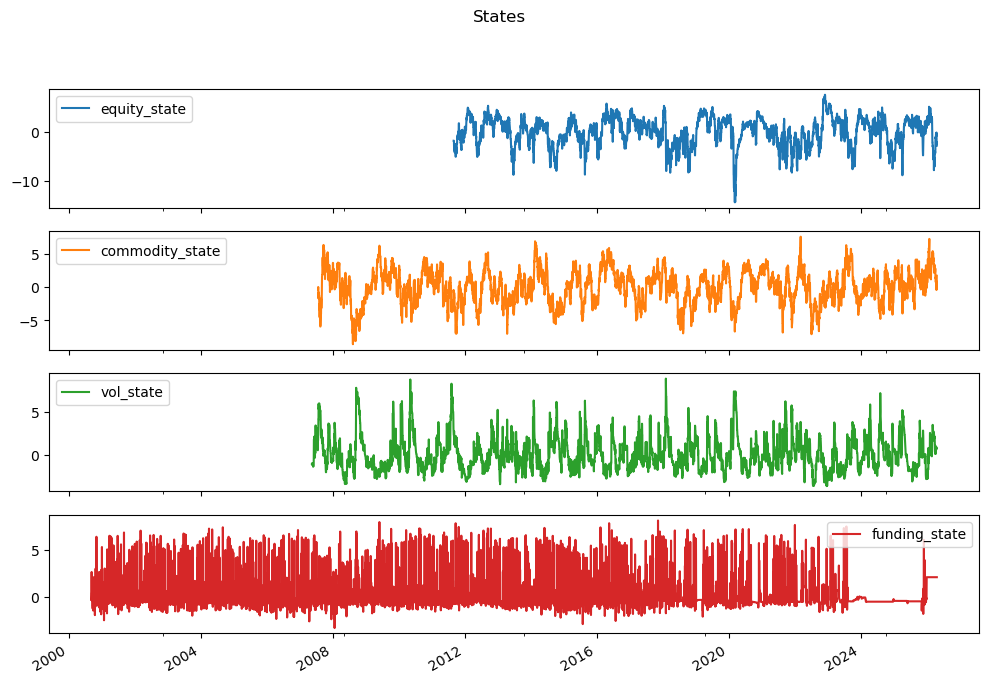


================ STATE CONDITIONAL RETURNS ================


State: equity_state
equity_state
0   -0.000243
1    0.000016
2    0.000157
Name: ret, dtype: float64

State: commodity_state
commodity_state
0   -0.000189
1   -0.000015
2    0.000134
Name: ret, dtype: float64

State: vol_state
vol_state
0    0.000070
1    0.000101
2   -0.000242
Name: ret, dtype: float64

State: funding_state
funding_state
0   -0.000086
1   -0.000102
2    0.000117
Name: ret, dtype: float64

================ STATE RETURN BAR PLOTS ================



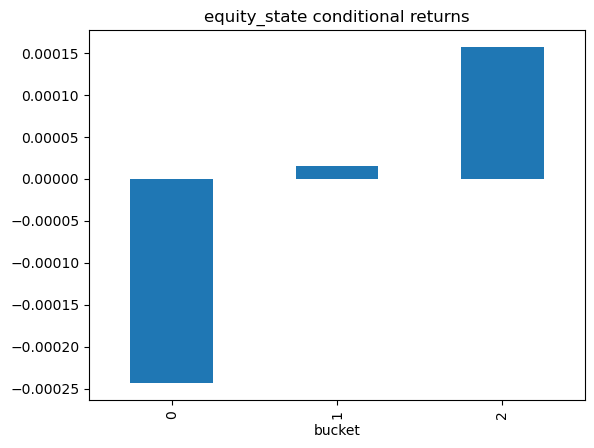

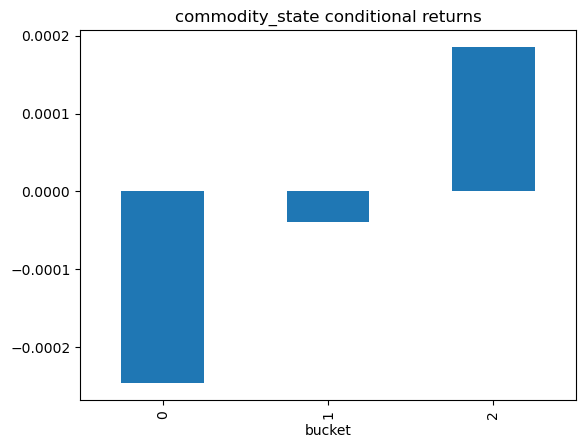

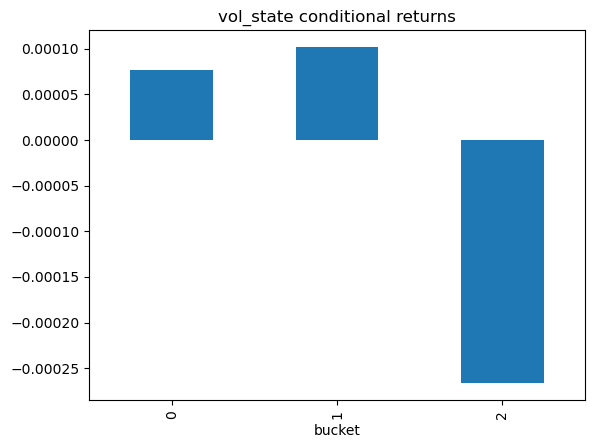

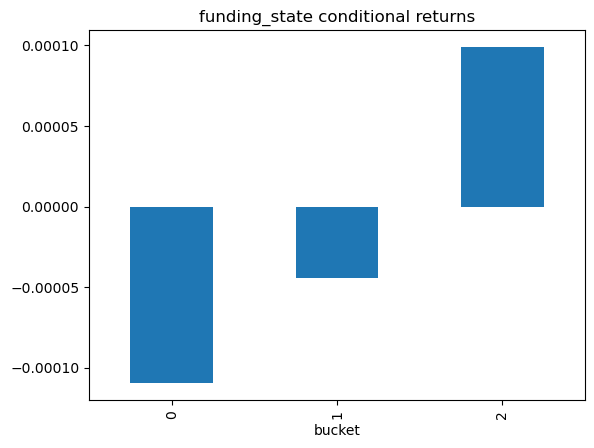

In [17]:
# Cell 17
# Run diagnostics

run_feature_diagnostics(
    equity_filtered=equity_filtered,
    commodity_filtered=commodity_filtered,
    vol_filtered=vol_filtered,
    funding_filtered=funding_filtered,
    equity_ic=equity_ic,
    commodity_ic=commodity_ic,
    vol_ic=vol_ic,
    funding_ic=funding_ic,
    states_df=states_df,
    returns_df=returns_df,
)

In [18]:
# Cell 18
# Save outputs

states_df.to_parquet("data/states_df.parquet")

equity_filtered.to_parquet("data/equity_features_clean.parquet")
commodity_filtered.to_parquet("data/commodity_features_clean.parquet")
vol_filtered.to_parquet("data/vol_features_clean.parquet")
funding_filtered.to_parquet("data/funding_features_clean.parquet")

equity_ic.to_parquet("data/equity_ic_diag.parquet")
commodity_ic.to_parquet("data/commodity_ic_diag.parquet")
vol_ic.to_parquet("data/vol_ic_diag.parquet")
funding_ic.to_parquet("data/funding_ic_diag.parquet")

equity_feature_results.to_parquet("data/equity_feature_results.parquet")
commodity_feature_results.to_parquet("data/commodity_feature_results.parquet")
vol_feature_results.to_parquet("data/vol_feature_results.parquet")
funding_feature_results.to_parquet("data/funding_feature_results.parquet")